#   Arabic Tashkeel (تشكيل) with Seq2Seq Transformer

In [ ]:
from typing import List
def compute_length_stats(sources: List[str], targets: List[str]) -> dict:
    """
    WHY: Before setting MAX_SRC_LEN and MAX_TGT_LEN, run this on your
    actual dataset. Don't guess — measure.
 
    Print the 95th percentile of source and target lengths, then set
    your limits to the 99th percentile (to cover 99% of samples without
    truncation). The remaining 1% will be truncated — that's acceptable.
    """
    import numpy as np
 
    src_lens = [len(s) for s in sources]
    tgt_lens = [len(t) for t in targets]
    ratios   = [len(t) / max(len(s), 1) for s, t in zip(sources, targets)]
 
    stats = {
        "src_p50":  int(np.percentile(src_lens, 50)),
        "src_p95":  int(np.percentile(src_lens, 95)),
        "src_p99":  int(np.percentile(src_lens, 99)),
        "tgt_p50":  int(np.percentile(tgt_lens, 50)),
        "tgt_p95":  int(np.percentile(tgt_lens, 95)),
        "tgt_p99":  int(np.percentile(tgt_lens, 99)),
        "ratio_mean": float(round(sum(ratios) / len(ratios), 2)),
        "ratio_max":  float(round(max(ratios), 2)),
    }
 
    print("=== Dataset Length Statistics ===")
    print(f"  Source p50={stats['src_p50']}  p95={stats['src_p95']}  p99={stats['src_p99']}")
    print(f"  Target p50={stats['tgt_p50']}  p95={stats['tgt_p95']}  p99={stats['tgt_p99']}")
    print(f"  tgt/src ratio: mean={stats['ratio_mean']}  max={stats['ratio_max']}")
    print(f"\n  → Recommended MAX_SRC_LEN = {stats['src_p99'] + 20}")
    print(f"  → Recommended MAX_TGT_LEN = {stats['tgt_p99'] + 40}")
 
    return stats


## Tokenizer


In [ ]:
#   Special tokens:
#       <PAD> = 0   — padding to batch variable-length sequences
#       <SOS> = 1   — start-of-sequence (decoder prompt)
#       <EOS> = 2   — end-of-sequence (decoder stop signal)
#       <UNK> = 3   — unknown character (fallback)
from typing import Dict, List
class ArabicCharTokenizer:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3
    SPECIAL = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
    
    def __init__(self):
        self.char2id: Dict[str,int]={}
        self.id2char: Dict[int,str]={}
        for i ,tok in enumerate(self.SPECIAL):
            self.char2id[tok]= i
            self.id2char[i]=tok

    def build_vocab(self, texts:List[str])->None:
        chars= set()
        for text in texts:
            chars.update(text)
        chars= sorted(chars) # deterministic order

        start_id= len(self.SPECIAL)
        for i, ch in enumerate(chars):
            self.char2id[ch] = start_id +i
            self.id2char[start_id+i]= ch
        print(f"[Tokenizer] Vocabulary size: {len(self.char2id)}") 
        
    
    def encode(self, text:str,add_sos:bool=False, add_eos:bool=True)-> List[int]:
        ids= []
        if add_sos:
            ids.append(self.SOS)
        for ch in text:
            ids.append(self.char2id.get(ch,self.UNK))
        if add_eos:
            ids.append(self.EOS)
        return ids
    def decode(self, ids:List[int], skip_speicals:bool=True)->str:
        chars=[]
        for i in ids:
            if skip_speicals and i in (self.PAD,self.SOS,self.EOS,self.UNK):
                continue
            chars.append(self.id2char.get(i,"?"))
        return "".join(chars)
   
    @property
    def vocab_size(self) -> int:
        return len(self.char2id)
    @property
    def vocabs(self)->Dict[str,int]:
        return self.char2id

## Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
from typing import List
#from .tokenizer import ArabicCharTokenizer
MAX_SRC_LEN=150 #max undiacritized chars per sample
MAX_TGT_LEN=500 #  max diacritized chars (includes harakat between chars)


class TashkeelDataset(Dataset):
    """Handle batching, shuffling and multiworker.

    Return:
        src_ids — encoded undiacritized source, padded to MAX_SRC_LEN
        tgt_ids — encoded diacritized target (WITH <SOS> prepended), padded
        tgt_labels — same as tgt_ids but SHIFTED LEFT by 1 (for teacher forcing)
    """
    def __init__(self,sources:List[str],
                 targets:List[str],
                 tokenizer:ArabicCharTokenizer,
                 max_src_len:int=MAX_SRC_LEN,
                 max_tgt_len:int=MAX_TGT_LEN):
        super().__init__()
        self.tokenizer=tokenizer
        self.max_src_len=max_src_len
        self.max_tgt_len=max_tgt_len

        self.pairs=[]
        for src,tgt in zip(sources,targets):
            src_ids=tokenizer.encode(src,add_sos=False,add_eos=True)
            # tgt_ids= tokenizer.encode(tgt,add_sos=True,add_eos=True)
            # #Labels = target shifted left 
            # tgt_labels=tokenizer.encode(tgt,add_sos=False,add_eos=True)
            tgt_full = tokenizer.encode(tgt, add_sos=False, add_eos=True)
            tgt_ids = [tokenizer.SOS] + tgt_full[:-1]
            # Labels = target shifted left (no SOS, but EOS included)
            tgt_labels = tgt_full
            #Truncate
            src_ids=src_ids[:max_src_len]
            tgt_ids=tgt_ids[:max_tgt_len]
            tgt_labels = tgt_labels[:max_tgt_len]

            self.pairs.append(
                (src_ids,tgt_ids,tgt_labels)
            )
    

    def __len__(self)->int:
        return len(self.pairs)
    
    def __getitem__(self,idx:int):

        src_ids,tgt_ids,tgt_lables= self.pairs[idx]
        return{
            "src_ids":torch.tensor(src_ids,dtype=torch.long),
            "tgt_ids":torch.tensor(tgt_ids,dtype=torch.long),
            "tgt_labels":torch.tensor(tgt_lables,dtype=torch.long)
        }
    



def collate_fn(batch:List[dict])->dict:
    """pad shorter ones,
    to the length of the longest in the batch (dynamic padding)."""

    PAD= ArabicCharTokenizer.PAD

    src_padded=torch.nn.utils.rnn.pad_sequence(
        [item['src_ids'] for item in batch],
        batch_first=True,padding_value=PAD
    )

    tgt_padded= torch.nn.utils.rnn.pad_sequence(
        [item['tgt_ids'] for item in batch],
        batch_first=True, padding_value=PAD
    )

    lbl_padded= torch.nn.utils.rnn.pad_sequence(
        [item['tgt_labels'] for item in batch],
        batch_first=True,padding_value=PAD
    )

    #padding mask
    src_key_padding_mask= (src_padded==PAD) 
    tgt_key_padding_mask= (tgt_padded==PAD)

    return{
        "src":src_padded,
        "tgt":tgt_padded,
        "labels":lbl_padded,
        "src_key_padding_mask":src_key_padding_mask,
        "tgt_key_padding_mask":tgt_key_padding_mask
        }

## scheduler

In [ ]:
import torch
class NoamScheduler:
    """Custom LR Scehdular
    """

    def __init__(self,
                 optimizer:torch.optim.Optimizer,
                 d_model:int,
                 warmup_steps:int=400):
        self.optimizer= optimizer
        self.d_model=d_model
        self.warmup_steps= warmup_steps
        self._step=0

    def step(self):
        self._step +=1
        lr= self._compute_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr']= lr

    def _compute_lr(self)->float:
        step= max(self._step,1)
        return(
            self.d_model ** (-0.5)
            * min(step ** (-0.5), step *  self.warmup_steps ** (-1.5) )
        )
        
        

## Model

### Positional Encoding

In [ ]:

import torch
import math
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model:int,max_len:int=500,dropout:float=0.1):
        super().__init__()
        self.dropout=torch.nn.Dropout(dropout)

        pe= torch.zeros(max_len,d_model)
        position= torch.arange(0,max_len,dtype=torch.float).unsqueeze(1) #(max_len, 1)

        div_term=torch.exp(
            torch.arange(0,d_model,2,dtype=torch.float)
            * (-math.log(10000.0)/ d_model)
        )
        #use sin for even dims & consin for odd
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe= pe.unsqueeze(0)
        self.register_buffer("pe",pe) #as a part of state

    def forward(self,x:torch.Tensor)->torch.Tensor:
       x = x + self.pe[:, :x.size(1), :]
       return self.dropout(x)


### Transformer

In [ ]:
import torch
import math
from typing import Optional

class TashkeelTransformer(torch.nn.Module):
    def __init__(self,
                src_vocab_size:int,
                tgt_vocab_size:int,
                d_model:int=256,
                n_heads:int=8,
                num_encoder_layers:int=3,
                num_decoder_layers:int=3,
                dim_feedforward:int=512,
                dropout:float=0.1,
                max_seq_len:int=500,
                pad_idx:int=0
                ):
        super().__init__()
        self.d_model= d_model
        self.pad_idx= pad_idx
        self.tgt_vocab_size= tgt_vocab_size

        # Embedding

        self.src_embedding= torch.nn.Embedding(src_vocab_size,d_model,padding_idx=pad_idx)
        self.tgt_embedding= torch.nn.Embedding(tgt_vocab_size,d_model,padding_idx=pad_idx)
        self.scale= math.sqrt(d_model) 
        
        self.pos_encoding= PositionalEncoding(d_model,max_seq_len,dropout)


        # Transformer

        self.transformer= torch.nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        self.output_projection= torch.nn.Linear(d_model,tgt_vocab_size)
        self.output_projection.weight = self.tgt_embedding.weight
        self._init_weights()


    def _init_weights(self):
        for p in self.parameters():
            if p.dim() >1 :
                torch.nn.init.xavier_uniform_(p)
        torch.nn.init.normal_(self.src_embedding.weight,mean=0, std=0.01)
        torch.nn.init.normal_(self.tgt_embedding.weight,mean=0,std=0.01)

    @staticmethod
    def make_causal_mask(sz:int,device:torch.device) -> torch.Tensor:
        mask= torch.triu(torch.ones(sz,sz,device=device),diagonal=1)
        return mask.masked_fill(mask==1 ,float("-inf"))

    def encode(self,
               src:torch.Tensor,
               src_key_padding_mask:Optional[torch.Tensor]=None)->torch.Tensor:
        src_emb= self.pos_encoding(self.src_embedding(src) * self.scale)
        return self.transformer.encoder(
            src_emb,
            src_key_padding_mask=src_key_padding_mask)
    

    def decoder(self,
                tgt:torch.Tensor,
                memory:torch.Tensor,
                tgt_mask:Optional[torch.Tensor]=None,
                tgt_key_padding_mask:Optional[torch.Tensor]=None,
                memory_key_padding_mask:Optional[torch.Tensor]=None)->torch.Tensor:
        tgt_emb= self.pos_encoding(self.tgt_embedding(tgt) * self.scale)

        return self.transformer.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )   
    

    def forward(self,
                src:torch.Tensor,
                tgt:torch.Tensor,
                src_key_padding_mask: Optional[torch.Tensor] = None,
                tgt_key_padding_mask: Optional[torch.Tensor] = None,
                )-> torch.Tensor:
        tgt_len = tgt.size(1)
        device = src.device

        tgt_mask = self.make_causal_mask(tgt_len, device)
        memory = self.encode(src, src_key_padding_mask)

        decoder_out = self.decoder(
            tgt, memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )

        logits = self.output_projection(decoder_out) 
        return logits


## metrics

In [33]:

from typing import List, Tuple
import re
import unicodedata
import editdistance
def extract_base_and_diacritics(text: str) -> List[Tuple[str, str]]:
    """
    Extract (base_char, diacritics) pairs from Arabic text.
    Handles shadda+haraka combinations correctly.
    
    Returns: List of tuples like [('ك', 'َ'), ('ت', 'َ'), ('ب', '')]
    """
    # Arabic base letters range
    BASE_PATTERN = re.compile(r'[\u0621-\u064A]')  # Arabic letters
    DIACRITIC_PATTERN = re.compile(r'[\u064B-\u0652\u0670]')  # Harakat + shadda
    
    pairs = []
    i = 0
    while i < len(text):
        char = text[i]
        if BASE_PATTERN.match(char):
            # Collect all diacritics following this base char
            diacritics = ""
            j = i + 1
            while j < len(text) and DIACRITIC_PATTERN.match(text[j]):
                diacritics += text[j]
                j += 1
            pairs.append((char, diacritics))
            i = j
        else:
            # Non-base characters (spaces, punctuation): keep as-is with empty diacritics
            pairs.append((char, ""))
            i += 1
    return pairs


def align_on_base_chars(
    pred_pairs: List[Tuple[str, str]],
    ref_pairs: List[Tuple[str, str]]
) -> List[Tuple[Tuple[str, str], Tuple[str, str]]]:
    """
    Align prediction and reference pairs on BASE CHARACTERS using greedy alignment.
    
    Returns: List of (pred_pair, ref_pair) tuples, where either can be (None, None) for gaps.
    
    Why greedy? It's O(n) and works well for tashkeel where insertions/deletions are rare.
    For production with noisy outputs, consider Levenshtein alignment (see below).
    """
    aligned = []
    i, j = 0, 0
    
    while i < len(pred_pairs) or j < len(ref_pairs):
        # Both sequences exhausted
        if i >= len(pred_pairs) and j >= len(ref_pairs):
            break
        
        # Prediction exhausted: remaining ref chars are deletions
        if i >= len(pred_pairs):
            aligned.append((None, ref_pairs[j]))
            j += 1
            continue
        
        # Reference exhausted: remaining pred chars are insertions
        if j >= len(ref_pairs):
            aligned.append((pred_pairs[i], None))
            i += 1
            continue
        
        pred_base, pred_diac = pred_pairs[i]
        ref_base, ref_diac = ref_pairs[j]
        
        # Match on base character
        if pred_base == ref_base:
            aligned.append((pred_pairs[i], ref_pairs[j]))
            i += 1
            j += 1
        else:
            # Mismatch: try to resync by looking ahead (simple heuristic)
            # Look for the next matching base char within a small window
            window = 3
            found = False
            
            # Try advancing in prediction
            for k in range(1, min(window + 1, len(pred_pairs) - i)):
                if pred_pairs[i + k][0] == ref_base:
                    # Insertions in prediction: mark skipped pred chars as errors
                    for skip in range(k):
                        aligned.append((pred_pairs[i + skip], None))
                    i += k
                    found = True
                    break
            
            if not found:
                # Try advancing in reference
                for k in range(1, min(window + 1, len(ref_pairs) - j)):
                    if ref_pairs[j + k][0] == pred_base:
                        # Deletions in prediction: mark skipped ref chars as errors
                        for skip in range(k):
                            aligned.append((None, ref_pairs[j + skip]))
                        j += k
                        found = True
                        break
            
            if not found:
                # No resync found: treat as substitution error
                aligned.append((pred_pairs[i], ref_pairs[j]))
                i += 1
                j += 1
    
    return aligned


def compute_der(predicted: str, reference: str) -> float:
    """
    Compute Diacritic Error Rate with BASE-CHARACTER ALIGNMENT.
    
    DER = (# diacritic mismatches + # base char insertions/deletions) / (# base chars in reference)
    
    This handles:
    - Model output shorter/longer than reference
    - Insertions/deletions of base characters
    - Shadda+haraka combinations
    """
    if not reference.strip():
        return 0.0 if not predicted.strip() else 1.0
    
    pred_pairs = extract_base_and_diacritics(predicted)
    ref_pairs = extract_base_and_diacritics(reference)
    
    # Count reference base characters (denominator)
    ref_base_count = sum(1 for base, _ in ref_pairs if base.strip())
    if ref_base_count == 0:
        return 0.0
    
    aligned = align_on_base_chars(pred_pairs, ref_pairs)
    
    errors = 0
    for pred_pair, ref_pair in aligned:
        if pred_pair is None:
            # Deletion: reference char missing in prediction
            errors += 1
        elif ref_pair is None:
            # Insertion: extra char in prediction
            errors += 1
        else:
            pred_base, pred_diac = pred_pair
            ref_base, ref_diac = ref_pair
            # Base chars should match due to alignment, but double-check
            if pred_base != ref_base:
                errors += 1  # Substitution error
            elif pred_diac != ref_diac:
                errors += 1  # Diacritic mismatch
    
    return errors / ref_base_count


def compute_der_with_stats(predicted: str, reference: str) -> dict:
    """
    Extended DER computation with diagnostic stats for debugging.
    """
    pred_pairs = extract_base_and_diacritics(predicted)
    ref_pairs = extract_base_and_diacritics(reference)
    
    ref_base_count = sum(1 for base, _ in ref_pairs if base.strip())
    if ref_base_count == 0:
        return {"DER": 0.0, "errors": 0, "total": 0, "alignment_issues": 0}
    
    aligned = align_on_base_chars(pred_pairs, ref_pairs)
    
    errors = 0
    diacritic_errors = 0
    base_errors = 0  # insertions + deletions + substitutions
    alignment_issues = 0
    
    for pred_pair, ref_pair in aligned:
        if pred_pair is None:
            errors += 1
            base_errors += 1
        elif ref_pair is None:
            errors += 1
            base_errors += 1
        else:
            pred_base, pred_diac = pred_pair
            ref_base, ref_diac = ref_pair
            if pred_base != ref_base:
                errors += 1
                base_errors += 1
                alignment_issues += 1
            elif pred_diac != ref_diac:
                errors += 1
                diacritic_errors += 1
    
    return {
        "DER": errors / ref_base_count,
        "diacritic_DER": diacritic_errors / ref_base_count,
        "base_char_DER": base_errors / ref_base_count,
        "total_errors": errors,
        "diacritic_errors": diacritic_errors,
        "base_char_errors": base_errors,
        "reference_length": ref_base_count,
        "alignment_issues": alignment_issues,
    }

def normalize_arabic(text: str) -> str:
    """Normalize Unicode, collapse spaces, and strip control chars for fair comparison."""
    text = unicodedata.normalize("NFC", text)
    text = " ".join(text.split())  # collapse multiple spaces
    return text

def exact_match(predictions: List[str], references: List[str]) -> float:
    """Proportion of exactly matching prediction-reference pairs."""
    if not predictions:
        return 0.0
    norm_preds = [normalize_arabic(p) for p in predictions]
    norm_refs = [normalize_arabic(r) for r in references]
    correct = sum(p == r for p, r in zip(norm_preds, norm_refs))
    return correct / len(predictions)

def cer(predicted: str, reference: str) -> float:
    """
    Character Error Rate (CER) using Levenshtein distance.
    CER = (S + D + I) / N_ref
    """
    ref = normalize_arabic(reference)
    pred = normalize_arabic(predicted)
    if len(ref) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return editdistance.eval(pred, ref) / len(ref)

def compute_corpus_metrics(predictions: List[str], references: List[str]) -> Dict[str, float]:
    """Unified evaluation: DER + CER + Exact Match."""
    
    
    der_scores = [compute_der(p, r) for p, r in zip(predictions, references)]
    cer_scores = [cer(p, r) for p, r in zip(predictions, references)]
    em = exact_match(predictions, references)
    return {
        "DER_mean": sum(der_scores) / len(der_scores),
        "DER_std":  (sum((d - sum(der_scores)/len(der_scores))**2 for d in der_scores) / len(der_scores))**0.5,
        "CER_mean": sum(cer_scores) / len(cer_scores),
        "Exact_Match": em,
        "n_samples": len(predictions)
    }
    # return {
    #     "DER": der_scores["DER"],
    #     "diacritic_DER": der_scores["diacritic_DER"],
    #     "base_char_DER": der_scores["base_char_DER"],
    #     "total_errors": der_scores["total_errors"],
    #     "diacritic_errors": der_scores["diacritic_errors"],
    #     "base_char_errors": der_scores["base_char_errors"],
    #     "reference_length": der_scores["reference_length"],
    #     "alignment_issues": der_scores["alignment_issues"],

        
    #     "CER_mean": sum(cer_scores) / len(cer_scores),
    #     "Exact_Match": em,
    #     "n_samples": len(predictions)
    # }

## greedy search decode

In [25]:
import torch
import torch.nn.functional as F
from typing import List

MAX_TGT_LEN=500
@torch.no_grad()
def greedy_decode(
    model: TashkeelTransformer,
    src_ids: List[int],
    tokenizer: ArabicCharTokenizer,
    device: torch.device,
    max_len: int = 500
) -> str:
    model.eval()
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    memory = model.encode(src)
    
   
    max_mask = model.make_causal_mask(max_len, device)
    
    
    generated = torch.full((1, 1), tokenizer.SOS, dtype=torch.long, device=device)
    
    for step in range(max_len - 1):
        tgt_len = generated.size(1)
        
       
        tgt_mask = max_mask[:tgt_len, :tgt_len]
        
        decoder_out = model.decoder(generated, memory, tgt_mask=tgt_mask)
        logits = model.output_projection(decoder_out[:, -1, :])
        
        
        next_token = logits.argmax(dim=-1, keepdim=True) 
        generated = torch.cat([generated, next_token], dim=1)
        
        if next_token.item() == tokenizer.EOS:
            break
            
    return tokenizer.decode(generated[0].tolist())


## Beam search decode


In [26]:
@torch.no_grad()
def beam_search_decode(
    model: TashkeelTransformer,
    src_ids: List[int],
    tokenizer: ArabicCharTokenizer,
    device: torch.device,
    beam_size: int = 4,
    max_len: int = 500,
    length_penalty: float = 0.6,
) -> str:
    model.eval()
    
  
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    memory = model.encode(src)
    
    
    max_mask = model.make_causal_mask(max_len, device)
    
    
    sequences = torch.full((1, 1), tokenizer.SOS, dtype=torch.long, device=device)
    scores = torch.zeros(1, device=device)
    
    completed_sequences = []
    completed_scores = []
    
    for step in range(max_len - 1):
        current_beam_size = sequences.size(0)
        current_len = sequences.size(1)
        
        
        mem_expanded = memory.expand(current_beam_size, -1, -1).contiguous()
        
       
        tgt_mask = max_mask[:current_len, :current_len]
        
        
        decoder_out = model.decoder(sequences, mem_expanded, tgt_mask=tgt_mask)
        logits = model.output_projection(decoder_out[:, -1, :]) )
        log_probs = F.log_softmax(logits, dim=-1)
        
       
        next_scores = scores.unsqueeze(1) + log_probs 
        next_scores_flat = next_scores.view(-1)
        
        k = min(beam_size, next_scores_flat.size(0))
        topk_scores, topk_ids = torch.topk(next_scores_flat, k)
        
        beam_ids = topk_ids // tokenizer.vocab_size
        token_ids = topk_ids % tokenizer.vocab_size
        
        sequences = sequences[beam_ids]
        sequences = torch.cat([sequences, token_ids.unsqueeze(1)], dim=1)
        scores = topk_scores
        
        is_eos = (token_ids == tokenizer.EOS)
        
        if is_eos.any():
            for i in range(k):
                if is_eos[i]:
                    seq = sequences[i].tolist()
                    score = scores[i].item()
                    norm_score = score / (len(seq) ** length_penalty)
                    completed_sequences.append(seq)
                    completed_scores.append(norm_score)
            
            active_mask = ~is_eos
            sequences = sequences[active_mask]
            scores = scores[active_mask]
            
        if sequences.size(0) == 0:
            break
            
    if not completed_sequences:
        best_idx = torch.argmax(scores).item()
        best_seq = sequences[best_idx].tolist()
        best_score = scores[best_idx].item()
        norm_score = best_score / (len(best_seq) ** length_penalty)
        completed_sequences.append(best_seq)
        completed_scores.append(norm_score)
        
    best_overall_idx = max(range(len(completed_scores)), key=lambda i: completed_scores[i])
    best_seq = completed_sequences[best_overall_idx]
    
    return tokenizer.decode(best_seq)

## Train Loop

In [12]:

from torch.utils.data import DataLoader
import torch
import os
import sys
from tqdm.auto import tqdm
import pandas as pd
import random
def train_epoch(model: TashkeelTransformer,
                dataloader:DataLoader,
                optimizer: torch.optim.Optimizer,
                scheduler,
                criterion:torch.nn.CrossEntropyLoss,
                 device:torch.device,
                  clip_grad_norm:float = 1.0 )->float:
    
    model.train()
    total_loss=0.0
    n_batches=0

    for batch in dataloader:
        src= batch['src'].to(device)
        tgt= batch['tgt'].to(device)
        labels= batch['labels'].to(device)
        src_mask = batch["src_key_padding_mask"].to(device)
        tgt_mask = batch["tgt_key_padding_mask"].to(device)

        logits= model(src,tgt,src_key_padding_mask=src_mask)

        B, T,V= logits.shape

        loss= criterion(logits.reshape(B * T, V) ,labels.reshape(B*T))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),clip_grad_norm)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()
        
        total_loss += loss.item()
        n_batches +=1
    return total_loss / max(n_batches, 1)


def evaluate(model: TashkeelTransformer,
             dataloader: DataLoader,
             criterion: torch.nn.CrossEntropyLoss,
             device:torch.device)-> float:
    model.eval()
    total_loss= 0.0
    n_batches=0

    for batch in dataloader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)
        labels = batch["labels"].to(device)
        src_mask = batch["src_key_padding_mask"].to(device)
 
        logits = model(src, tgt, src_key_padding_mask=src_mask)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), labels.reshape(B * T))
 
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)





def train(model:TashkeelTransformer,
          train_loader:DataLoader,
          val_loader:DataLoader,
           val_sources: List[str],  
            val_targets: List[str],  
          device: torch.device,
          der_eval_every: int = 5,      
        der_sample_size: int = 50,     
        der_beam_size: int = 1,        
          
          num_epochs:int =20,
          learning_rate:float= 1e-4,
          checkpoint_dir:str="checkpoints"):
    os.makedirs(checkpoint_dir,exist_ok=True)
    history=[]
    optimizer= torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.98),   #Transformer paper values
        eps=1e-9,
        weight_decay=0.01
    )

    scheduler= NoamScheduler(optimizer=optimizer,d_model=model.d_model)
    criterion = torch.nn.CrossEntropyLoss(
        ignore_index=ArabicCharTokenizer.PAD,
        label_smoothing=0.1,
    )

    best_val_loss = float("inf")
    
    for epoch in tqdm(range(1, num_epochs +1)):
        train_loss= train_epoch(model,train_loader,optimizer,scheduler,criterion,device)
        val_loss= evaluate(model,val_loader,criterion,device)
        
        log_msg = (
            f"Epoch {epoch:3d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )
            
        print(log_msg)


        if val_loss < best_val_loss:
            best_val_loss= val_loss
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                },
                os.path.join(checkpoint_dir, "best_model.pt"),
            )
            print(f"Saved best model (val_loss={val_loss:.4f})")

        history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        })

        
        pd.DataFrame(history).to_csv(f"{checkpoint_dir}/training_log.csv", index=False)


In [13]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import json
with open("/kaggle/input/datasets/iamagamy/arabic-sentences-diacritics/data.json", 'r')as f:
    data= json.load(f)


sources = [s for item in data for s in item["src"]]

targets = [t for item in data for t in item["tgt"]]

compute_length_stats(sources,targets)

=== Dataset Length Statistics ===
  Source p50=90  p95=124  p99=173
  Target p50=147  p95=196  p99=199
  tgt/src ratio: mean=1.6  max=2.33

  → Recommended MAX_SRC_LEN = 193
  → Recommended MAX_TGT_LEN = 239


{'src_p50': 90,
 'src_p95': 124,
 'src_p99': 173,
 'tgt_p50': 147,
 'tgt_p95': 196,
 'tgt_p99': 199,
 'ratio_mean': 1.6,
 'ratio_max': 2.33}

In [14]:
len(sources[0])

117

In [15]:
len(targets[0])

193

## Train

In [16]:
import torch
from sklearn.model_selection import train_test_split
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
D_MODEL = 256
NUM_EPOCHS = 60


## Get data

import json
with open("/kaggle/input/datasets/iamagamy/arabic-sentences-diacritics/data.json", 'r')as f:
    data= json.load(f)
sources = [s for item in data for s in item["src"]]

targets = [t for item in data for t in item["tgt"]]

print(f"Loaded {len(sources)} sentence pairs.")


tokenizer = ArabicCharTokenizer()
tokenizer.build_vocab(sources + targets)  


# _____ Data splitting
train_src, temp_src, train_tgt, temp_tgt = train_test_split(
    sources,
    targets,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Split temp into 10% val and 10% test
val_src, test_src, val_tgt, test_tgt = train_test_split(
    temp_src,
    temp_tgt,
    test_size=0.5,
    random_state=42,
    shuffle=True
)
print(f" Training len : {len(train_src)}\n Val len : {len(val_src)} \n Test len : {len(test_src)}  ")

## prepare datta
train_dataset = TashkeelDataset(train_src, train_tgt, tokenizer)
val_dataset = TashkeelDataset(val_src, val_tgt, tokenizer)

train_loader = DataLoader(
  train_dataset, batch_size=BATCH_SIZE, shuffle=True,
  collate_fn=collate_fn, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
  val_dataset, batch_size=BATCH_SIZE, shuffle=False,
  collate_fn=collate_fn, num_workers=2, pin_memory=True
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

## build model
model = TashkeelTransformer(
        src_vocab_size=tokenizer.vocab_size,
        tgt_vocab_size=tokenizer.vocab_size,
        
        d_model=D_MODEL,
        n_heads=8,
        num_encoder_layers=3,
        num_decoder_layers=3,
        dim_feedforward=512,
        dropout=0.1,
        pad_idx=ArabicCharTokenizer.PAD,
    ).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Start training

train(model=model,
      train_loader=train_loader,
      val_loader=val_loader,
      val_sources=val_src,   
    val_targets=val_tgt, 
      device=DEVICE,
      num_epochs=NUM_EPOCHS)

Loaded 52570 sentence pairs.
[Tokenizer] Vocabulary size: 56
 Training len : 42056
 Val len : 5257 
 Test len : 5257  
Train batches: 1315 | Val batches: 165
Model parameters: 3,983,416


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch   1 | Train Loss: 1.7898 | Val Loss: 0.9606 | LR: 1.72e-03
Saved best model (val_loss=0.9606)
Epoch   2 | Train Loss: 0.9510 | Val Loss: 0.8653 | LR: 1.22e-03
Saved best model (val_loss=0.8653)
Epoch   3 | Train Loss: 0.8840 | Val Loss: 0.8388 | LR: 9.95e-04
Saved best model (val_loss=0.8388)
Epoch   4 | Train Loss: 0.8570 | Val Loss: 0.8230 | LR: 8.62e-04
Saved best model (val_loss=0.8230)
Epoch   5 | Train Loss: 0.8413 | Val Loss: 0.8147 | LR: 7.71e-04
Saved best model (val_loss=0.8147)
Epoch   6 | Train Loss: 0.8312 | Val Loss: 0.8085 | LR: 7.04e-04
Saved best model (val_loss=0.8085)
Epoch   7 | Train Loss: 0.8234 | Val Loss: 0.8026 | LR: 6.51e-04
Saved best model (val_loss=0.8026)
Epoch   8 | Train Loss: 0.8172 | Val Loss: 0.7993 | LR: 6.09e-04
Saved best model (val_loss=0.7993)
Epoch   9 | Train Loss: 0.8126 | Val Loss: 0.7963 | LR: 5.75e-04
Saved best model (val_loss=0.7963)
Epoch  10 | Train Loss: 0.8083 | Val Loss: 0.7937 | LR: 5.45e-04
Saved best model (val_loss=0.7937)


### Plot Training Result

In [17]:
!ls /kaggle/working/checkpoints/

best_model.pt  training_log.csv


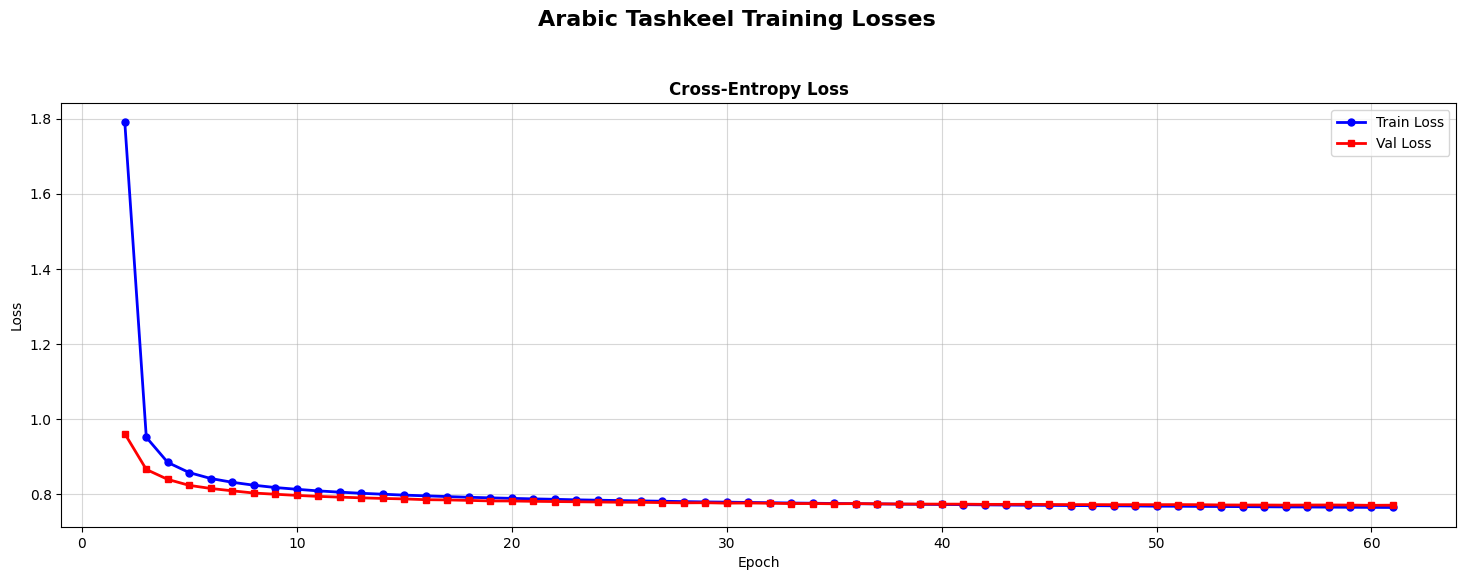

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
csv_path= "/kaggle/working/checkpoints/training_log.csv"
df = pd.read_csv(csv_path)
df = df.sort_values("epoch").reset_index(drop=True)
epochs = df["epoch"]
title="Arabic Tashkeel Training Losses"
fig, ax = plt.subplots(figsize=(18, 5.5))
fig.suptitle(title, fontsize=16, fontweight="bold", y=1.05)

ax.plot(epochs, df["train_loss"], "b-", label="Train Loss", marker="o", markersize=5, linewidth=2)
ax.plot(epochs, df["val_loss"], "r-", label="Val Loss", marker="s", markersize=5, linewidth=2)
ax.set_title("Cross-Entropy Loss", fontsize=12, fontweight="semibold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.5)
plt.show()


## Eval

In [34]:
from tqdm.auto import tqdm
def evaluate_model(model, sources, targets, tokenizer, device, max_samples=None):
    predictions = []
    references = []

    if max_samples:
        sources = sources[:max_samples]
        targets = targets[:max_samples]
    with torch.no_grad():
        for src_text, tgt_text in tqdm(zip(sources, targets),total= len(sources)):
            src_ids = tokenizer.encode(src_text)
    
            pred = greedy_decode(model, src_ids, tokenizer, device)
    
            predictions.append(pred)
            references.append(tgt_text)

    return compute_corpus_metrics(predictions,references)
device= 'cuda' 



eval_result= evaluate_model(model=model,
                           sources=test_src,
                           targets=test_tgt,
                           tokenizer=tokenizer,
                           device=device)
print(eval_result)

  0%|          | 0/5257 [00:00<?, ?it/s]

{'DER_mean': 0.07600671189513523, 'DER_std': 0.13587549736638027, 'CER_mean': 0.04709102002796905, 'Exact_Match': 0.24386532242723988, 'n_samples': 5257}


In [35]:
from pprint import pprint

pprint(eval_result)

{'CER_mean': 0.04709102002796905,
 'DER_mean': 0.07600671189513523,
 'DER_std': 0.13587549736638027,
 'Exact_Match': 0.24386532242723988,
 'n_samples': 5257}


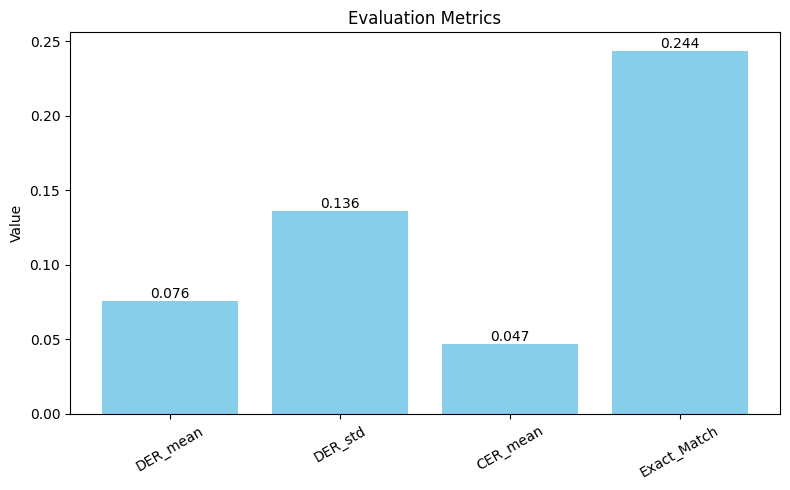

In [40]:
metrics = {k: v for k, v in eval_result.items() if k != "n_samples"}

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(metrics.keys(), metrics.values(), color="skyblue")

ax.set_title("Evaluation Metrics")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=30)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [41]:
import json
from pathlib import Path

Path("assets").mkdir(exist_ok=True)


tokenizer_data = {
    "char2id": tokenizer.char2id,
    "id2char": {str(k): v for k, v in tokenizer.id2char.items()},
    "vocab_size": tokenizer.vocab_size
}
with open("assets/tokenizer.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer_data, f, ensure_ascii=False, indent=2)


config = {
    "d_model": 256, 
    "nhead": 8, 
    "num_encoder_layers": 3,
    "num_decoder_layers": 3, 
    "dim_feedforward": 512, 
    "dropout": 0.1,
    "max_src_len": 150, 
    "max_tgt_len": 500,
    "vocab_size": tokenizer.vocab_size  
}
with open("assets/config.json", "w") as f:
    json.dump(config, f, indent=2)

In [42]:
import re
class ArabicTextChunker:
    SENTENCE_ENDINGS = re.compile(r'([.؟!،]\s*)')

    def __init__(self,
                 max_chunk_size:int=140,
                 min_chunk_size:int=30,         
                overlap_chars:int=30
                 ):
    
        self.max_chunk_size=max_chunk_size
        self.min_chunk_size=min_chunk_size
        self.overlap_chars=overlap_chars
    

    def chunk(self, text:str)->List[str]:
        if len(text) <=self.max_chunk_size:
            return [text.strip()]
    

        chunks= []
        start=0
        while start < len(text):
            end= start + self.max_chunk_size

            if end>= len(text):
                ch= text[start:].strip()
                if ch:
                    chunks.append(ch)
                break


            segment= text[start:end]
            split_point= self._find_best_split(segment,start)

            if split_point is None:
                last_space= segment.rfind(' ')
                if last_space > self.min_chunk_size:
                    split_point= start + last_space +1
                else:
                    split_point = end


             
            

            ch = text[start:split_point].strip()
            if ch:
                chunks.append(ch)
            
            if self.overlap_chars > 0 and start > 0:
                start= split_point - self.overlap_chars
                if start < 0:
                    start= 0 
            else:
                start = split_point

        return chunks

    
    def _find_best_split(self,segment:str,global_start:int)->int:
        for i in range(len(segment) - 1, self.min_chunk_size - 1, -1):
            if segment[i] in '.؟!،':
                return global_start + i + 1  
        return None
    
  

In [43]:
class TashkeelPredictor:
    def __init__(self,
                  checkpoint_path="checkpoints",
                  assets_path="assets",
                    device=None):
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
        
        # Load config & tokenizer
        with open(f"{assets_path}/config.json", "r") as f:
            cfg = json.load(f)
        with open(f"{assets_path}/tokenizer.json", "r", encoding="utf-8") as f:
            tok_data = json.load(f)
        
        ## Define the txt chunker
        self.chunker = ArabicTextChunker(
           
          overlap_chars=0
        )
        
        self.tokenizer = ArabicCharTokenizer()
        self.tokenizer.char2id = {k: int(v) for k, v in tok_data["char2id"].items()}
        self.tokenizer.id2char = {int(k): v for k, v in tok_data["id2char"].items()}
        self.max_src_len = cfg["max_src_len"]
        
        # Initialize model with saved hyperparameters
        self.model = TashkeelTransformer(
            src_vocab_size=cfg["vocab_size"], tgt_vocab_size=cfg["vocab_size"],
            d_model=cfg["d_model"], n_heads=8,
            num_encoder_layers=cfg["num_encoder_layers"],
            num_decoder_layers=cfg["num_decoder_layers"],
            dim_feedforward=cfg["dim_feedforward"],
            dropout=cfg["dropout"], pad_idx=ArabicCharTokenizer.PAD
        ).to(self.device)
        
        # Load weights
        ckpt = torch.load(f"{checkpoint_path}/best_model.pt", map_location=self.device, weights_only=True)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.model.eval()
        print(f"Model loaded on {self.device}")


    def _diacritize_single(self, text: str, beam_size: int = 4)->str:
        src_ids = self.tokenizer.encode(text, add_sos=False, add_eos=True)
        max_len = self.max_src_len
        if len(src_ids) > max_len:
            src_ids = src_ids[:max_len]
        
        with torch.no_grad():
            return beam_search_decode(
                self.model, src_ids, self.tokenizer, self.device, beam_size=beam_size
            )
           


    def diacritize(self, text: str, use_beam: bool = True, beam_size: int = 4) -> str:
        """Diacritize a single Arabic sentence."""
        if len(text.strip()) == 0: return ""
        
        if len(text.strip()) <= self.chunker.max_chunk_size:
            return self._diacritize_single(text.strip(), beam_size)

        chunks= self.chunker.chunk(text.strip())
        print(f"chunks :{chunks}")
        diacritized_chunks = [
            self._diacritize_single(chunk,  beam_size)
            for chunk in chunks
        ]
        return " ".join(diacritized_chunks)


    def diacritize_batch(self, texts: list, use_beam: bool = True, beam_size: int = 4) -> list:
        """Process multiple sentences efficiently."""
        return [self.diacritize(t, use_beam, beam_size) for t in texts]
    

In [45]:
predictor = TashkeelPredictor()

text = """
هذا من فضل ربي
""".strip()

result = predictor.diacritize(text, use_beam=True, beam_size=4)
print(f"Input:  {text}")
print(f"Output: {result}")


Model loaded on cuda
Input:  هذا من فضل ربي
Output: هَذَا مِنْ فَضْلِ رَبِّي


In [46]:
!zip -r model.zip  "/kaggle/working/assets" "/kaggle/working/checkpoints"

  adding: kaggle/working/assets/ (stored 0%)
  adding: kaggle/working/assets/config.json (deflated 36%)
  adding: kaggle/working/assets/tokenizer.json (deflated 68%)
  adding: kaggle/working/checkpoints/ (stored 0%)
  adding: kaggle/working/checkpoints/training_log.csv (deflated 52%)
  adding: kaggle/working/checkpoints/best_model.pt (deflated 11%)
